# Taller: Análisis de Sentimientos en Tweets en Español (TASS 2018)

Pipeline completo con todos los pasos implementados:
1. TF-IDF word + char con negación.
2. Features manuales sobre texto crudo.
3. Lexicón ampliado estilo ML-SentiCon (sin dependencias externas).
4. SMOTE en lugar de RandomOverSampler.
5. GridSearchCV para ajuste de hiperparámetros.
6. Ensemble VotingClassifier (LinearSVC + LR + ComplementNB).
7. Análisis de ejemplos mal clasificados de NEU y NONE.

Fixes aplicados:
- net_score separado en net_pos / net_neg para que ComplementNB no reciba negativos.
- max_iter=5000 en LinearSVC para evitar ConvergenceWarning.
- multi_class eliminado de LogisticRegression (deprecado en sklearn 1.5).

## 1. Configuración del entorno

In [68]:
import os
import sys

PATH = os.getcwd()
PROJECT_ROOT = os.path.dirname(PATH)
SRC_PATH = os.path.join(PROJECT_ROOT, 'src')
DIR_DATA = os.path.join(PROJECT_ROOT, 'data', 'raw', 'tass') + os.sep

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DIR_DATA:", DIR_DATA)
print("logic existe:", os.path.exists(os.path.join(SRC_PATH, 'logic', 'text_processing.py')))

PROJECT_ROOT: /home/daniel-linux/Universidad/NLP-5029
DIR_DATA: /home/daniel-linux/Universidad/NLP-5029/data/raw/tass/
logic existe: True


## 2. Importación de librerías

In [69]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.sparse import hstack, csr_matrix

from sklearn.preprocessing import LabelEncoder
from logic.text_processing import TextProcessing

# Features
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier

# Evaluación y búsqueda
from sklearn.model_selection import ShuffleSplit, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    recall_score, f1_score, accuracy_score, precision_score
)

# Desbalance
from imblearn.over_sampling import SMOTE

## 3. Inicialización de utilidades

In [70]:
tp = TextProcessing()
le = LabelEncoder()

Language: Text Processing
es: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 4. Carga de datos

In [71]:
data_train = pd.read_csv(DIR_DATA + 'tass2018_es_train.csv', sep=',')
data_test = pd.read_csv(DIR_DATA + 'tass2018_es_test.csv', sep=',')

print(f"Train: {len(data_train)} | Test: {len(data_test)}")
data_train[:5]

Train: 1008 | Test: 506


,tweetid,user,content,date,lang,sentiment/polarity/value
0,768213876278165504,OnceBukowski,-Me caes muy bien \n-Tienes que jugar más part...,2016-08-23 22:30:35,es,NONE
1,768213567418036224,anahorxn,@myendlesshazza a. que puto mal escribo\n\nb. ...,2016-08-23 22:29:21,es,N
2,768212591105703936,martitarey13,@estherct209 jajajaja la tuya y la d mucha gen...,2016-08-23 22:25:29,es,N
3,768221670255493120,endlessmilerr,Quiero mogollón a @AlbaBenito99 pero sobretodo...,2016-08-23 23:01:33,es,P
4,768221021300264964,JunoWTFL,Vale he visto la tia bebiendose su regla y me ...,2016-08-23 22:58:58,es,N


In [72]:
data_test[:5]

,tweetid,user,content,date,lang,sentiment/polarity/value
0,770976639173951488,noseashetero,@noseashetero 1000/10 de verdad a ti que voy a...,2016-08-31 13:28:49,es,P
1,771092421866389508,Templelx,@piscolabisaereo @HistoriaNG @SPosteguillo las...,2016-08-31 21:08:54,es,P
2,771092111429083136,esskuu94,"Al final han sido 3h Bueno, mañana tengo fies...",2016-08-31 21:07:40,es,P
3,771092070572449796,__ariadna9,@Jorge_Ruiz14 yo no tengo tiempo para esas cos...,2016-08-31 21:07:30,es,N
4,771094192508600320,_cristtina15_,@_MissChaotic_ ves ese brillo? es un coso que ...,2016-08-31 21:15:56,es,N


## 5. Features manuales sobre texto CRUDO

Se calculan ANTES de tp.transformer porque:
- remove_patterns elimina ! y ?
- proper_encoding elimina tildes y caracteres especiales
- Los emojis se reemplazan por [EMOJI] perdiendo su valencia positiva/negativa

In [73]:
POSITIVE_EMOJIS = set('😀😁😂🤣😃😄😅😆😊😍🥰😘❤👍🎉✨💪🙌👏💯🔥')
NEGATIVE_EMOJIS = set('😢😭😡🤬😠😤😞😔😟😣💔👎😒😑😶🙄😪😫😩')

def extract_manual_features(texts):
    features = []
    for text in texts:
        n_pos_emoji = sum(1 for c in text if c in POSITIVE_EMOJIS)
        n_neg_emoji = sum(1 for c in text if c in NEGATIVE_EMOJIS)
        n_total_emoji = n_pos_emoji + n_neg_emoji
        n_exclamation = text.count('!')
        n_question = text.count('?')
        n_mention = text.count('@')
        n_hashtag = text.count('#')
        n_caps = sum(1 for c in text if c.isupper())
        ratio_caps = n_caps / max(len(text), 1)
        n_elongated = len(re.findall(r'(.)\1{2,}', text))
        n_words = len(text.split())
        features.append([
            n_pos_emoji, n_neg_emoji, n_total_emoji,
            n_exclamation, n_question,
            n_mention, n_hashtag,
            ratio_caps, n_elongated,
            n_words,
        ])
    return csr_matrix(np.array(features, dtype=np.float32))

## 6. Lexicón ampliado en español

Lexicón ampliado estilo ML-SentiCon con más de 100 palabras por polaridad.
Todas SIN tildes porque proper_encoding ya las eliminó del texto.

**Fix ComplementNB:** net_score = pos - neg puede ser negativo y ComplementNB
no acepta valores negativos. Lo separamos en:
- net_pos = max(0, pos - neg)  → cuánto domina lo positivo
- net_neg = max(0, neg - pos)  → cuánto domina lo negativo
Ambos siempre >= 0, sin perder información.

In [74]:
POSITIVE_WORDS = {
    'bueno', 'buena', 'buenos', 'buenas', 'excelente', 'genial', 'increible',
    'feliz', 'alegre', 'maravilloso', 'maravillosa', 'fantastico', 'fantastica',
    'perfecto', 'perfecta', 'bonito', 'bonita', 'hermoso', 'hermosa', 'lindo',
    'linda', 'estupendo', 'estupenda', 'magnifico', 'magnifica', 'brillante',
    'fabuloso', 'fabulosa', 'espectacular', 'admirable', 'encantador', 'rico',
    'rica', 'positivo', 'positiva', 'optimo', 'optima', 'grandioso', 'grandiosa',
    'sublime', 'radiante', 'precioso', 'preciosa', 'delicioso', 'deliciosa',
    'amor', 'alegria', 'exito', 'logro', 'victoria', 'triunfo', 'felicidad',
    'esperanza', 'ilusion', 'orgullo', 'satisfaccion', 'placer', 'dicha',
    'gozo', 'paz', 'armonia', 'progreso', 'bienestar', 'salud', 'amistad',
    'celebracion', 'fiesta', 'premio', 'honor', 'gloria',
    'amar', 'querer', 'ganar', 'celebrar', 'disfrutar', 'agradecer', 'apreciar',
    'admirar', 'apoyar', 'mejorar', 'crecer', 'brillar', 'sonreir', 'reir',
    'triunfar', 'lograr', 'conseguir', 'superar', 'avanzar', 'prosperar',
    'bien', 'mejor', 'gracias', 'bravo', 'viva', 'ole', 'crack', 'chevere',
    'bacano', 'chido', 'padre', 'bendito', 'bendita', 'felizmente',
}

NEGATIVE_WORDS = {
    'malo', 'mala', 'malos', 'malas', 'terrible', 'horrible', 'pesimo',
    'pesima', 'fatal', 'triste', 'asqueroso', 'asquerosa', 'vergonzoso',
    'lamentable', 'deplorable', 'nefasto', 'nefasta', 'patetico', 'patetica',
    'detestable', 'odioso', 'odiosa', 'maldito', 'maldita', 'estupido',
    'estupida', 'idiota', 'inutil', 'falso', 'falsa', 'corrupto', 'corrupta',
    'violento', 'violenta', 'injusto', 'injusta', 'miserable',
    'odio', 'asco', 'verguenza', 'fracaso', 'crisis', 'catastrofe', 'desastre',
    'corrupcion', 'mentira', 'estafa', 'abuso', 'injusticia', 'miedo', 'terror',
    'angustia', 'desesperacion', 'dolor', 'sufrimiento', 'muerte', 'tragedia',
    'problema', 'conflicto', 'guerra', 'violencia', 'crimen', 'amenaza',
    'peligro', 'desgracia', 'caos', 'escandalo', 'humillacion', 'decepcion',
    'frustracion', 'rabia', 'furia', 'ira', 'rencor',
    'odiar', 'perder', 'fallar', 'fracasar', 'sufrir', 'llorar', 'destruir',
    'arruinar', 'hundir', 'robar', 'mentir', 'engañar', 'traicionar',
    'abandonar', 'rechazar', 'insultar', 'agredir', 'humillar',
    'mal', 'peor', 'jamas', 'ladron', 'mentiroso', 'mentirosa', 'hipocrita',
    'lamentablemente', 'tristemente', 'desgraciadamente',
}

def extract_lexicon_features(texts):
    features = []
    for text in texts:
        words = set(text.lower().split())
        pos_score = len(words & POSITIVE_WORDS)
        neg_score = len(words & NEGATIVE_WORDS)
        net = pos_score - neg_score
        # Separamos net en dos features >= 0 para compatibilidad con ComplementNB
        net_pos = max(0, net)
        net_neg = max(0, -net)
        n_words = max(len(words), 1)
        pos_ratio = pos_score / n_words
        neg_ratio = neg_score / n_words
        features.append([pos_score, neg_score, net_pos, net_neg, pos_ratio, neg_ratio])
    return csr_matrix(np.array(features, dtype=np.float32))

## 7. Manejo de negación

Se aplica DESPUÉS de transformer. Palabras sin tildes.

In [75]:
NEGATION_WORDS = {
    'no', 'ni', 'nunca', 'jamas', 'tampoco',
    'sin', 'nada', 'nadie', 'ningun', 'ninguna'
}
NEGATION_WINDOW = 4

def apply_negation(text):
    words = text.split()
    result = []
    negating = 0
    for word in words:
        clean = word.strip('.,!?;:')
        if clean in NEGATION_WORDS:
            negating = NEGATION_WINDOW
            result.append(word)
        elif negating > 0:
            result.append('NEG_' + word)
            negating -= 1
            if re.search(r'[.!?]', word):
                negating = 0
        else:
            result.append(word)
    return ' '.join(result)

## 8. Preprocesamiento completo

Orden correcto:
1. Features manuales sobre texto crudo (emojis, !, ?, mayúsculas).
2. tp.transformer (limpieza y normalización).
3. apply_negation sobre texto limpio.
4. Features de lexicón sobre texto limpio.

In [76]:
x_train_raw = data_train['content'].tolist()
x_test_raw = data_test['content'].tolist()

y_train = data_train['sentiment/polarity/value'].values
y_test = data_test['sentiment/polarity/value'].values

# Paso 1: features manuales sobre texto crudo
x_train_manual = extract_manual_features(x_train_raw)
x_test_manual = extract_manual_features(x_test_raw)

# Paso 2: transformer
x_train_clean = [tp.transformer(row) for row in x_train_raw]
x_test_clean = [tp.transformer(row) for row in x_test_raw]

# Paso 3: negación
x_train_proc = [apply_negation(t) if t else '' for t in x_train_clean]
x_test_proc = [apply_negation(t) if t else '' for t in x_test_clean]

# Paso 4: lexicón
x_train_lex = extract_lexicon_features(x_train_proc)
x_test_lex = extract_lexicon_features(x_test_proc)

print(f"x_train: {len(x_train_proc)} | x_test: {len(x_test_proc)}")

x_train: 1008 | x_test: 506


## 9. Vectorización: TF-IDF word + char

In [77]:
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    strip_accents='unicode',
)

tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=3,
    max_df=0.95,
    strip_accents='unicode',
)

In [78]:
x_train_w = tfidf_word.fit_transform(x_train_proc)
x_test_w = tfidf_word.transform(x_test_proc)

x_train_c = tfidf_char.fit_transform(x_train_proc)
x_test_c = tfidf_char.transform(x_test_proc)

x_train = hstack([x_train_w, x_train_c, x_train_manual, x_train_lex])
x_test = hstack([x_test_w, x_test_c, x_test_manual, x_test_lex])

print(f"Dimensión train: {x_train.shape}")
print(f"Dimensión test : {x_test.shape}")

Dimensión train: (1008, 10690)
Dimensión test : (506, 10690)


## 10. Análisis de distribución de clases

In [79]:
print('**Sample train:', sorted(Counter(y_train).items()))

**Sample train: [('N', 418), ('NEU', 133), ('NONE', 139), ('P', 318)]


In [80]:
print('**Sample test:', sorted(Counter(y_test).items()))

**Sample test: [('N', 219), ('NEU', 69), ('NONE', 62), ('P', 156)]


## 11. GridSearchCV para ajuste de hiperparámetros

Buscamos el mejor valor de C para LinearSVC antes de construir el ensemble.
Usamos f1_macro como métrica porque nos importan las clases minoritarias (NEU, NONE).

In [81]:
# Oversampling previo para el grid search
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
x_train_gs, y_train_gs = ros.fit_resample(x_train, y_train)

svc_grid = GridSearchCV(
    LinearSVC(max_iter=5000, class_weight='balanced', random_state=42),
    param_grid={'C': [0.1, 0.5, 1.0, 5.0, 10.0]},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
svc_grid.fit(x_train_gs, y_train_gs)
best_C = svc_grid.best_params_['C']
print(f"Mejor C para LinearSVC: {best_C}")
print(f"Mejor F1 macro en CV  : {round(svc_grid.best_score_ * 100, 2)}%")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iteration

Mejor C para LinearSVC: 0.5
Mejor F1 macro en CV  : 81.86%


/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 12. Esquema de validación: ShuffleSplit

In [82]:
k_fold = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)

## 13. Oversampling con SMOTE solo sobre train

SMOTE genera ejemplos sintéticos interpolando entre vecinos cercanos,
más diverso que RandomOverSampler que solo duplica.
Solo se aplica sobre train, el test queda intacto.

Requiere al menos k_neighbors+1 ejemplos por clase.
Usamos k_neighbors=3 para clases pequeñas como NEU y NONE.

In [83]:
smote = SMOTE(random_state=42, k_neighbors=3)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print('**SMOTE train:', sorted(Counter(y_train_res).items()))

**SMOTE train: [('N', 418), ('NEU', 418), ('NONE', 418), ('P', 418)]


## 14. Modelo: Ensemble VotingClassifier

Fixes aplicados:
- LinearSVC: max_iter=5000 para evitar ConvergenceWarning.
- LogisticRegression: sin multi_class (deprecado en sklearn 1.5).
- ComplementNB: solo recibe features >= 0 (garantizado por el lexicón corregido).

In [84]:
svc = CalibratedClassifierCV(
    # max_iter=5000 resuelve el ConvergenceWarning
    LinearSVC(C=best_C, max_iter=5000, class_weight='balanced', random_state=42),
    cv=3
)

lr = LogisticRegression(
    C=5.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    # multi_class eliminado — deprecado en sklearn 1.5, ahora siempre es multinomial
    random_state=42
)

cnb = CalibratedClassifierCV(
    ComplementNB(alpha=0.1),
    cv=3
)

softmax = VotingClassifier(
    estimators=[('svc', svc), ('lr', lr), ('cnb', cnb)],
    voting='soft'
)

## 15. Métricas de evaluación

In [85]:
accuracies_scores = []
recalls_scores = []
precisions_scores = []
f1_scores = []

## 16. Entrenamiento y validación cruzada

Oversampling dentro de cada fold para métricas honestas.

In [89]:
from tqdm import tqdm

for train_index, test_index in tqdm(k_fold.split(x_train_res, y_train_res), total=k_fold.n_splits, desc="CV"):
    data_train_fold = x_train_res[train_index]
    target_train_fold = y_train_res[train_index]

    data_test_fold = x_train_res[test_index]
    target_test_fold = y_train_res[test_index]

    smote_fold = SMOTE(random_state=42, k_neighbors=3)
    data_train_fold, target_train_fold = smote_fold.fit_resample(data_train_fold, target_train_fold)

    softmax.fit(data_train_fold, target_train_fold)
    predict = softmax.predict(data_test_fold)

    accuracies_scores.append(accuracy_score(target_test_fold, predict))
    recalls_scores.append(recall_score(target_test_fold, predict, average='macro'))
    precisions_scores.append(precision_score(target_test_fold, predict, average='weighted', zero_division=0))
    f1_scores.append(f1_score(target_test_fold, predict, average='weighted'))


CV:   0%|          | 0/10 [00:00<?, ?it/s]/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
CV:  10%|█         | 1/10 [02:40<24:04, 160.51s/it]/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_bas

## 17. Resultados promedio en validación

In [90]:
average_recall = round(np.mean(recalls_scores) * 100, 2)
average_precision = round(np.mean(precisions_scores) * 100, 2)
average_f1 = round(np.mean(f1_scores) * 100, 2)
average_accuracy = round(np.mean(accuracies_scores) * 100, 2)

In [91]:
average_recall

np.float64(81.41)

## 18. Evaluación final sobre el conjunto de prueba

In [92]:
softmax.fit(x_train_res, y_train_res)

y_predict = []
for features in x_test:
    features = features.reshape(1, -1)
    value = softmax.predict(features)[0]
    y_predict.append(value)

classification = classification_report(y_test, y_predict, zero_division=0)
confusion = confusion_matrix(y_predict, y_test)

/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/daniel-linux/Universidad/NLP-5029/.venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [93]:
output_result = {
    'F1-score': average_f1,
    'Accuracy': average_accuracy,
    'Recall': average_recall,
    'Precision': average_precision,
    'Classification Report\n': classification,
    'Confusion Matrix\n': confusion
}

In [94]:
for item, val in output_result.items():
    print('{0} {1}'.format(item, val))

F1-score 81.11
Accuracy 81.47
Recall 81.41
Precision 81.36
Classification Report
               precision    recall  f1-score   support

           N       0.61      0.73      0.67       219
         NEU       0.19      0.10      0.13        69
        NONE       0.39      0.26      0.31        62
           P       0.61      0.67      0.64       156

    accuracy                           0.57       506
   macro avg       0.45      0.44      0.44       506
weighted avg       0.53      0.57      0.54       506

Confusion Matrix
 [[159  38  25  37]
 [ 19   7   5   5]
 [ 11   4  16  10]
 [ 30  20  16 104]]


## 19. Matriz de confusión visual

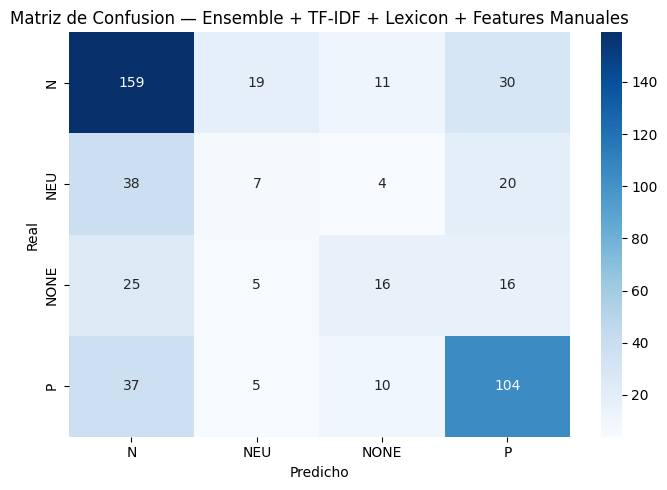

In [95]:
labels = sorted(set(y_test))
cm = confusion_matrix(y_test, y_predict, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=ax
)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusion — Ensemble + TF-IDF + Lexicon + Features Manuales')
plt.tight_layout()
plt.show()

## 20. Análisis de ejemplos mal clasificados (NEU y NONE)

Inspeccionamos los tweets donde el modelo falla en NEU y NONE
para entender la confusión semántica entre ambas clases y
orientar mejoras futuras del lexicón o del preprocesamiento.

In [96]:
df_test = data_test.copy()
df_test['predicted'] = y_predict
df_test['correct'] = df_test['sentiment/polarity/value'] == df_test['predicted']

# Errores en NEU
errors_neu = df_test[
    (df_test['sentiment/polarity/value'] == 'NEU') & (~df_test['correct'])
][['content', 'sentiment/polarity/value', 'predicted']]

print(f"Errores en NEU: {len(errors_neu)}")
errors_neu.head(10)

Errores en NEU: 62


,content,sentiment/polarity/value,predicted
6,@juankipua Es que en el Ojeando el año pasado ...,NEU,N
21,@CarlosSadness en ninguna porque no te he vist...,NEU,N
26,Este viernes iré al cine a ver #NoRespires par...,NEU,P
28,y lo peor de todo es que funcionaba maldita Ja...,NEU,N
44,Pero solo cojo 5 días porque me cambio de curro y,NEU,N
47,@LorasTyrellSer Yo también te puse algo bonito...,NEU,P
55,"@cardinaleconnor Mañana no :(, pero seguro que...",NEU,P
69,@FraanBMJ pero entiende que era nuestro sueño ...,NEU,N
74,"@TheFuzzCanyon gracias por etiquetarme, pero n...",NEU,N
88,"@_MrsCristina te amo, aunque parece que te has...",NEU,N


In [97]:
# Errores en NONE
errors_none = df_test[
    (df_test['sentiment/polarity/value'] == 'NONE') & (~df_test['correct'])
][['content', 'sentiment/polarity/value', 'predicted']]

print(f"Errores en NONE: {len(errors_none)}")
errors_none.head(10)

Errores en NONE: 46


,content,sentiment/polarity/value,predicted
7,"Bueno, estoy en la batalla final del Conquista...",NONE,P
11,@aladroqe Se me olvidaban los grandes @2qblog ...,NONE,P
13,@Majoras_Mark Por? Tenía pensado verla despué...,NONE,N
14,"@SoofRawr + ni el de al lado, la ""manita"" que ...",NONE,N
33,@baad_news es dirección de proyectos en empres...,NONE,NEU
61,"@GxDRadioGalega Correcció ""Nin se nos pasa pol...",NONE,N
66,@dfresneda_UNED pues la aludida ...y yo mismo....,NONE,N
101,"@eenriquelopez era por troleaer, usar store da...",NONE,N
131,@ranoeldelbar @HacheFilardi @Noel_PI Claro cla...,NONE,P
153,15. No me gusta el término \n16. Meh \n17. De...,NONE,N


In [98]:
# Con qué clases se confunde NEU
print("NEU predicho como:")
print(errors_neu['predicted'].value_counts())

NEU predicho como:
predicted
N       38
P       20
NONE     4
Name: count, dtype: int64


In [99]:
# Con qué clases se confunde NONE
print("NONE predicho como:")
print(errors_none['predicted'].value_counts())

NONE predicho como:
predicted
N      25
P      16
NEU     5
Name: count, dtype: int64
